In [1]:
import numpy as np
import torch

from torchgpe.bec2D import Gas
from torchgpe.bec2D.potentials import LinearPotential, Union, Callable, any_time_dependent_variable, time_dependent_variable
from torchgpe.utils.potentials import NonLinearPotential

import sys
import importlib
sys.path.append('..')

import two_component_variable_gas
importlib.reload(two_component_variable_gas)
from two_component_variable_gas import TwoComponentGas

import peden_two_state_3D
importlib.reload(peden_two_state_3D)
from peden_two_state_3D import set_two_component_molecular_mass, Trap3D, PedenDirectDDI3D, initialize_two_component_gaussian, print_imaginary_time_stiffness
from peden_two_state_3D import plot_central_x_slices, plot_xy_density, plot_xz_density, DEBYE_TO_C_M, print_beta_and_D_from_gas_stark_shift

/users/bohn/kexu8775/DielectricBEC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mass_amu = 220.0

# Quasi-2D / pancake trap.
# Frequencies must be angular frequencies, rad/s.
omega_x = 2 * np.pi * 400
omega_y = 2 * np.pi * 400
omega_z = 2 * np.pi * 4000

trap = Trap3D(
    omegax=omega_x,
    omegay=omega_y,
    omegaz=omega_z,
)

hbar = 1.054571817e-34
amu_to_kg = 1.6605e-27

ellz = np.sqrt(hbar/mass_amu/omega_z/amu_to_kg)
print(ellz)

1.0717348922623537e-07


In [3]:
N_up = int(50)
N_down = int(50)

gas = TwoComponentGas(
    element="87Rb",
    N_particles=(N_up, N_down),
    N_grid=64,
    grid_size=(3000e-9, 3000e-9, 1000e-9),
    adimensionalization_length=ellz,
    device="cuda",
)

set_two_component_molecular_mass(gas, mass_amu=mass_amu)

3.6531859516239997e-25

Initial Gaussian widths
-----------------------
sigma_x = 0.3389 um
sigma_y = 0.3389 um
sigma_z = 0.1072 um
tensor([3.1235e-09, 3.5448e-10], dtype=torch.float64)


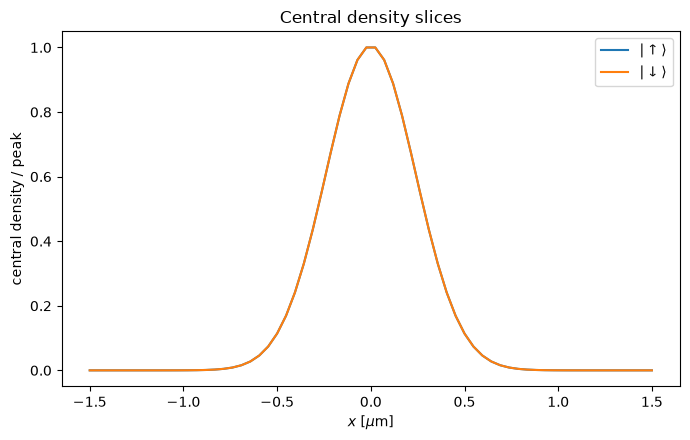

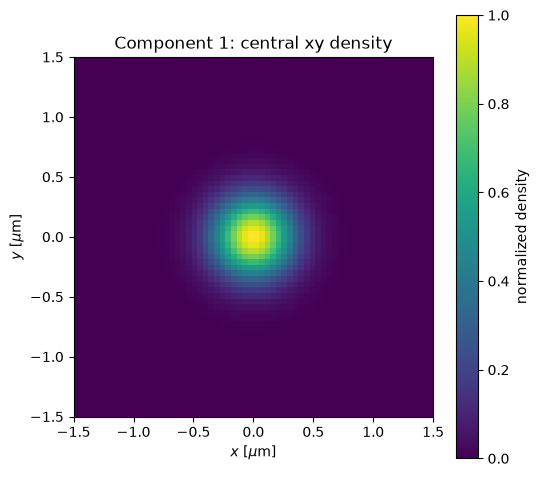

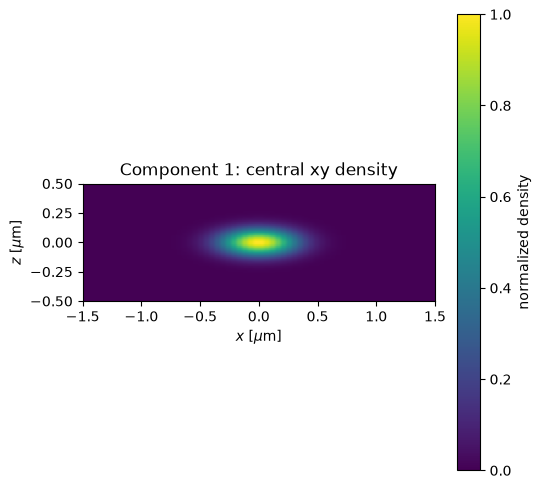

In [4]:
# Initialize.
initialize_two_component_gaussian(
    gas,
    omega_x=omega_x,
    omega_y=omega_y,
    omega_z=omega_z,
)

density = torch.abs(gas.psi[0]) ** 2

edge_max = torch.tensor([density[0,:,:].max(), density[:,:,0].max()])

print(edge_max / density.max().item())

plot_central_x_slices(gas, normalize=True)
plot_xy_density(gas, component=0, normalize=True)
plot_xz_density(gas, component=0, normalize=True)

In [5]:
import single_molecule_hamiltonian
importlib.reload(single_molecule_hamiltonian)
from single_molecule_hamiltonian import SingleMoleculeHamiltonian

from itp_energy_monitor import ground_state_energy_converged

import pickle
from IPython.display import clear_output

initialize_two_component_gaussian(
    gas,
    omega_x=omega_x,
    omega_y=omega_y,
    omega_z=omega_z,
)

# detuning (zero field separation)
Omega = 2 * omega_z

for beta in [1]:
    for D in np.arange(0, 1e-6, 1e-8):
        print("D = ", D)
        # stark shift energy difference (d0E is half of this)
        delta = 20 * beta * omega_z

        single_molecule = SingleMoleculeHamiltonian(
            delta=delta,
            Omega=Omega,
            phase=0.0,
        )

        d0_debye = np.sqrt(D / gas.N_total * (hbar * omega_z) * (ellz ** 3)) / DEBYE_TO_C_M
        ddi = PedenDirectDDI3D(
            d_up_debye=+d0_debye,
            d_down_debye=-d0_debye,
            polarization=(0.0, 0.0, 1.0),
        )

        # ddi.set_gas(gas)
        # ddi.on_propagation_begin()
        # ddi.print_couplings()

        # params = print_beta_and_D_from_gas_stark_shift(
        #     gas,
        #     d_debye=d0_debye,
        #     stark_shift_Hz=2*delta/(2*np.pi),       # dE/h = 500 Hz
        #     Delta_Hz=Omega/(2*np.pi),            # Delta/h = 1000 Hz
        #     omega_z_rad_s=2*np.pi*4000,
        # )

        # print_imaginary_time_stiffness(
        #     gas=gas,
        #     trap=trap,
        #     ddi=ddi,
        #     single_molecule=single_molecule,
        #     time_step=-1e-6j,
        # )

        monitor = ground_state_energy_converged(
            gas,
            potentials=[trap, ddi, single_molecule],
            time_step=-1e-6j,
            N_iterations=50_000,
            rtol=1e-12,
            compute_every=10,
            print_every=100,
            csv_path=f"saved/beta{beta:.2f}_D{int(D)}.csv"
        )

        with open(f"saved/beta{beta:.2f}_D{int(D*1e8)}.pkl", "wb") as f:
            data = {
                "gas" : gas,
                "summary" : monitor.summary()
            }
            pickle.dump(data, f)

        clear_output(wait=True)


D =  2e-08
Single-molecule Hamiltonian diagnostics
--------------------------------------
H_dim eigenvalues: [-10.05011207  10.05011207]
H_dim eigenvalue spread: 20.100224145055947
iter        0 | E=1.7777830461977842e+03 | dE/E=--- | E_Hz=7.110964879e+06 | T=3.342334646e+01 | V=4.808379291e-02 | DDI=1.734311381e+03 | Hsm=1.000023528e+01 | f=(1.000000,0.000000)


Ground state:   0%|          | 0/50000 [00:00<?]

Ground state:   0%|          | 1/50000 [00:00<2:55:52]

Ground state:   0%|          | 2/50000 [00:00<2:54:27]

Ground state:   0%|          | 3/50000 [00:00<2:53:59]

...

Ground state:   0%|          | 17/50000 [00:03<2:57:26]

Ground state:   0%|          | 18/50000 [00:03<2:57:11]

Ground state:   0%|          | 19/50000 [00:04<2:56:57]

Ground state:   0%|          | 19/50000 [00:04<3:00:41]


KeyboardInterrupt: 

In [30]:
d0_debye

np.float64(0.17124184264094056)

/home/bohn/kexu8775/DielectricBEC/peden_two_state_3D.py:433: RuntimeWarning: invalid value encountered in divide
  line_down = line_down / np.max(line_down)


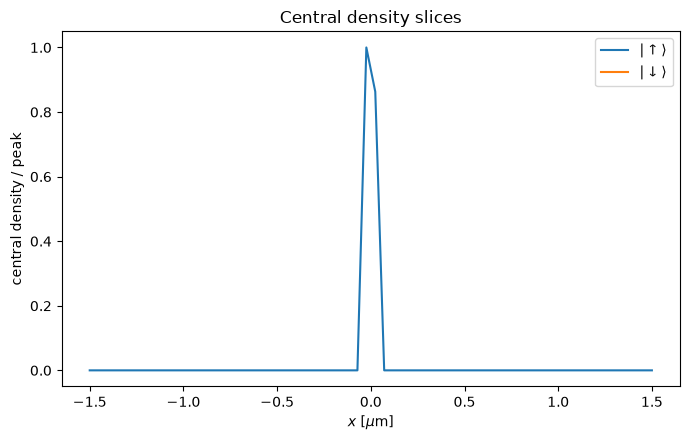

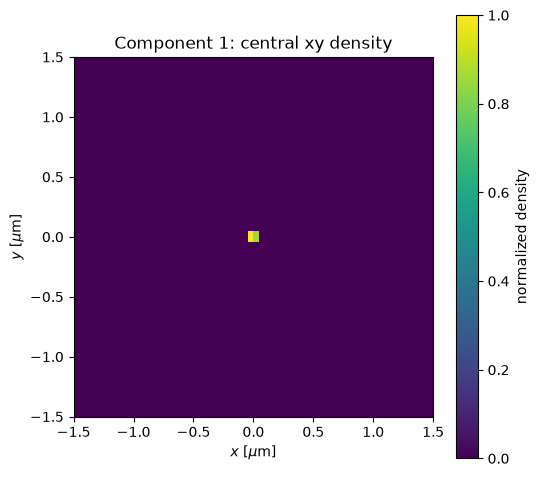

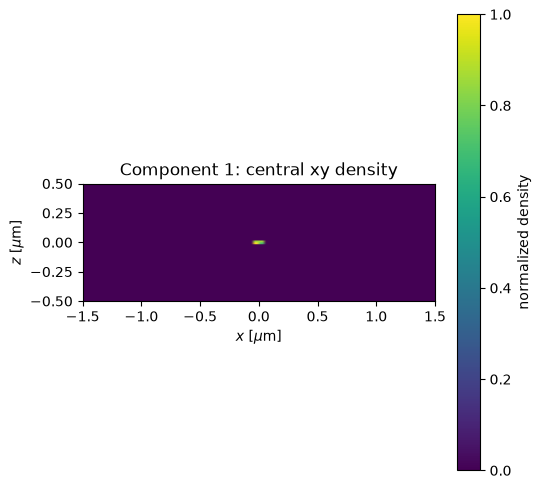

In [16]:
plot_central_x_slices(gas, normalize=True)
plot_xy_density(gas, component=0, normalize=True)
plot_xz_density(gas, component=0, normalize=True)